In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# ── Point this to your ingested data directory ──────────────────
DATA_DIR = r"C:\Users\shubh\OneDrive\Desktop\MLOPs\MLOPs-Project-02\artifacts\06_08_2026_22_22_06\data_ingestion\raw\chest_xray"
SPLITS     = ['train', 'test', 'val']
CLASSES    = ['NORMAL', 'PNEUMONIA']
print('Libraries loaded.')

Libraries loaded.


1. Class Distribution per split - how many images exist per class in each split

In [3]:
counts = defaultdict(dict)

for split in SPLITS:
    for cls in CLASSES:
        folder = os.path.join(DATA_DIR,split,cls)
        if os.path.exists(folder):
            counts[split][cls] = len(os.listdir(folder))
        else:
            counts[split][cls] = 0
            print(f'WARNING : Folder not found - {folder}')

print(f"{'Split':<10} {'NORMAL':<12} {'PNEUMONIA':<12} {'TOTAL':<10}")
print('-' * 45)

for split in SPLITS:
    normal    = counts[split]['NORMAL']
    pneumonia = counts[split]['PNEUMONIA']
    total     = normal + pneumonia
    print(f"{split:<10} {normal:<12} {pneumonia:<12} {total:<10}")

Split      NORMAL       PNEUMONIA    TOTAL     
---------------------------------------------
train      1341         3875         5216      
test       234          390          624       
val        8            8            16        


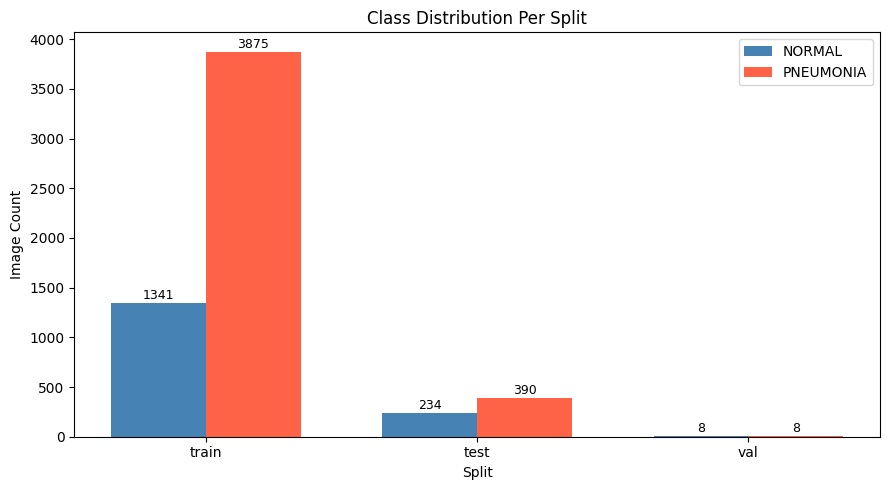

Saved: eda_class_distribution.png


In [23]:
# Bar chart — class distribution per split
x         = np.arange(len(SPLITS))
width     = 0.35
normal_counts    = [counts[s]['NORMAL']    for s in SPLITS]
pneumonia_counts = [counts[s]['PNEUMONIA'] for s in SPLITS]

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, normal_counts,    width, label='NORMAL',    color='steelblue')
bars2 = ax.bar(x + width/2, pneumonia_counts, width, label='PNEUMONIA', color='tomato')

ax.set_xlabel('Split')
ax.set_ylabel('Image Count')
ax.set_title('Class Distribution Per Split')
ax.set_xticks(x)
ax.set_xticklabels(SPLITS)
ax.legend()

# Add count labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150)
plt.show()
print('Saved: eda_class_distribution.png')

In [24]:
print('Class Imbalance Analysis\n')
for split in SPLITS:
    normal    = counts[split]['NORMAL']
    pneumonia = counts[split]['PNEUMONIA']
    if normal == 0:
        print(f'{split}: No NORMAL images found — check your data directory.')
        continue
    ratio = pneumonia / normal
    print(f'{split}: PNEUMONIA/NORMAL ratio = {ratio:.2f}x', end='  →  ')
    if ratio < 2:
        print('Balanced ✅')
    elif ratio < 4:
        print('Moderate imbalance ⚠️  — use class_weight in loss function')
    else:
        print('Severe imbalance 🚨 — use class_weight + consider oversampling')

Class Imbalance Analysis

train: PNEUMONIA/NORMAL ratio = 2.89x  →  Moderate imbalance ⚠️  — use class_weight in loss function
test: PNEUMONIA/NORMAL ratio = 1.67x  →  Balanced ✅
val: PNEUMONIA/NORMAL ratio = 1.00x  →  Balanced ✅


In [25]:
# Sample up to 200 images from train to analyse sizes (avoids slow full scan)
SAMPLE_SIZE = 200
widths, heights = [], []
size_errors = []

for cls in CLASSES:
    folder = os.path.join(DATA_DIR, 'train', cls)
    files  = os.listdir(folder)[:SAMPLE_SIZE // 2]
    for fname in files:
        fpath = os.path.join(folder, fname)
        try:
            with Image.open(fpath) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except Exception:
            size_errors.append(fpath)

print(f'Sampled {len(widths)} images from train split.\n')
print(f'Width  — min: {min(widths)}px  max: {max(widths)}px  mean: {np.mean(widths):.0f}px')
print(f'Height — min: {min(heights)}px  max: {max(heights)}px  mean: {np.mean(heights):.0f}px')
print(f'\nUnique sizes: {len(set(zip(widths, heights)))}')
if len(set(zip(widths, heights))) == 1:
    print('All images are the same size ✅')
else:
    print('Images have varying sizes ⚠️  — resize to 224x224 in transformation step')

Sampled 200 images from train split.

Width  — min: 502px  max: 2396px  mean: 1457px
Height — min: 307px  max: 2025px  mean: 1105px

Unique sizes: 199
Images have varying sizes ⚠️  — resize to 224x224 in transformation step


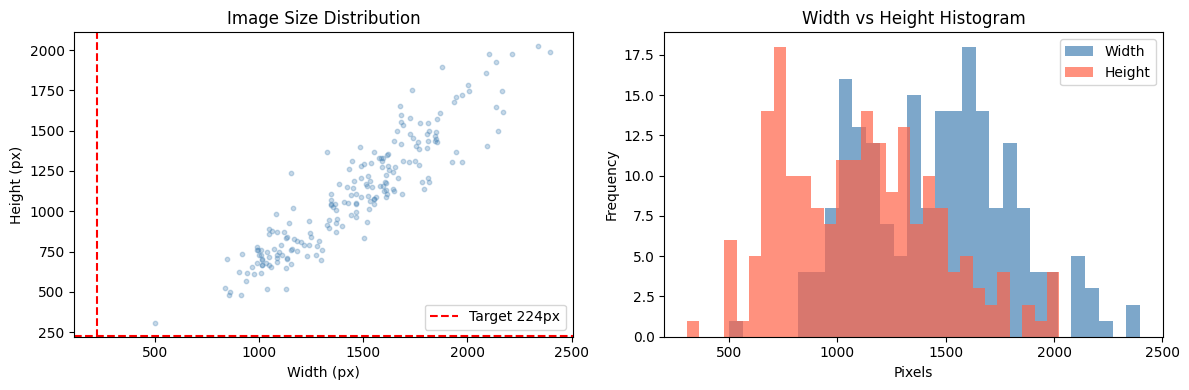

Saved: eda_image_sizes.png


In [26]:
# Scatter plot of image sizes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(widths, heights, alpha=0.3, color='steelblue', s=10)
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')
axes[0].set_title('Image Size Distribution')
axes[0].axvline(224, color='red', linestyle='--', label='Target 224px')
axes[0].axhline(224, color='red', linestyle='--')
axes[0].legend()

axes[1].hist(widths, bins=30, color='steelblue', alpha=0.7, label='Width')
axes[1].hist(heights, bins=30, color='tomato', alpha=0.7, label='Height')
axes[1].set_xlabel('Pixels')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Width vs Height Histogram')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_image_sizes.png', dpi=150)
plt.show()
print('Saved: eda_image_sizes.png')

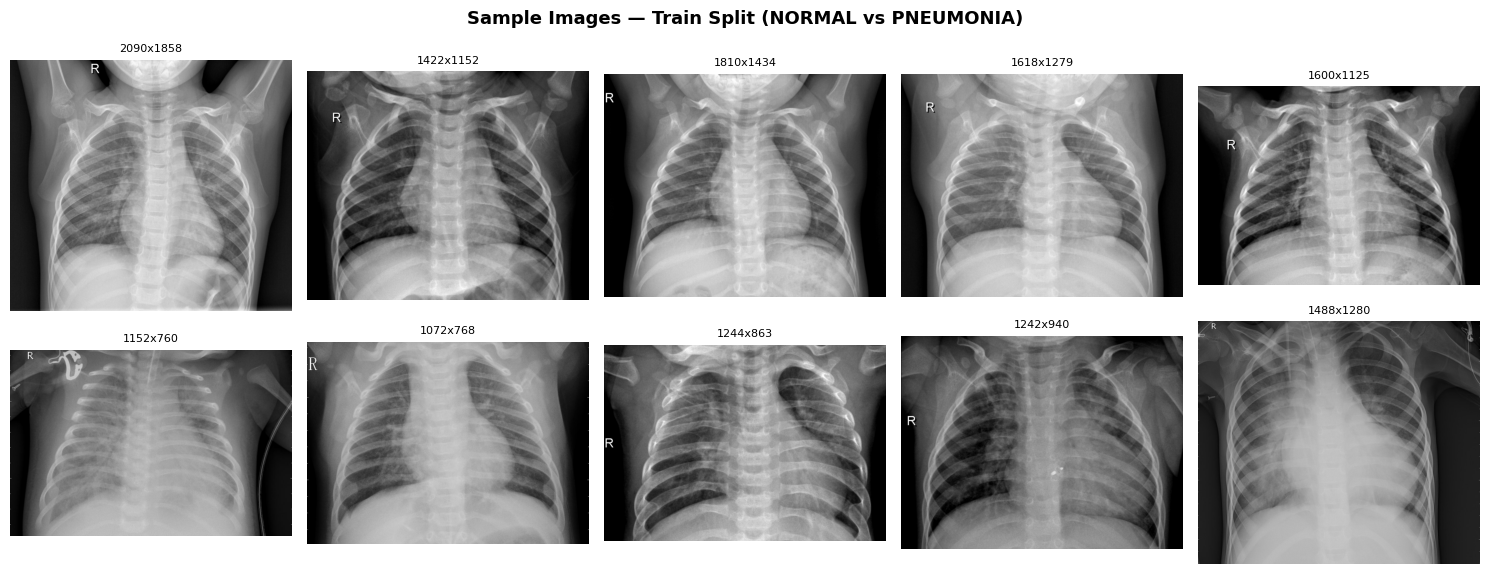

Saved: eda_sample_images.png


In [27]:
# Show 5 sample images per class from the train split
N_SAMPLES = 5
fig, axes = plt.subplots(len(CLASSES), N_SAMPLES, figsize=(15, 6))

for row, cls in enumerate(CLASSES):
    folder = os.path.join(DATA_DIR, 'train', cls)
    files  = os.listdir(folder)[:N_SAMPLES]
    for col, fname in enumerate(files):
        fpath = os.path.join(folder, fname)
        try:
            img = Image.open(fpath).convert('RGB')
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(cls, fontsize=12, fontweight='bold')
            axes[row, col].set_title(f'{img.size[0]}x{img.size[1]}', fontsize=8)
        except Exception as e:
            axes[row, col].set_title(f'Error\n{fname}', fontsize=7, color='red')
            axes[row, col].axis('off')

fig.suptitle('Sample Images — Train Split (NORMAL vs PNEUMONIA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_sample_images.png', dpi=150)
plt.show()
print('Saved: eda_sample_images.png')

In [28]:
# Compute mean pixel intensity per class (sample of 100 images each)
INTENSITY_SAMPLE = 100
intensity_data   = {cls: [] for cls in CLASSES}

for cls in CLASSES:
    folder = os.path.join(DATA_DIR, 'train', cls)
    files  = os.listdir(folder)[:INTENSITY_SAMPLE]
    for fname in files:
        fpath = os.path.join(folder, fname)
        try:
            img = Image.open(fpath).convert('L').resize((224, 224))  # grayscale for intensity
            intensity_data[cls].append(np.mean(np.array(img)))
        except Exception:
            pass

for cls in CLASSES:
    vals = intensity_data[cls]
    print(f'{cls:<12} — mean intensity: {np.mean(vals):.2f}  std: {np.std(vals):.2f}  '
          f'min: {np.min(vals):.2f}  max: {np.max(vals):.2f}')

NORMAL       — mean intensity: 119.58  std: 14.40  min: 83.78  max: 157.48
PNEUMONIA    — mean intensity: 122.32  std: 17.31  min: 73.50  max: 162.85


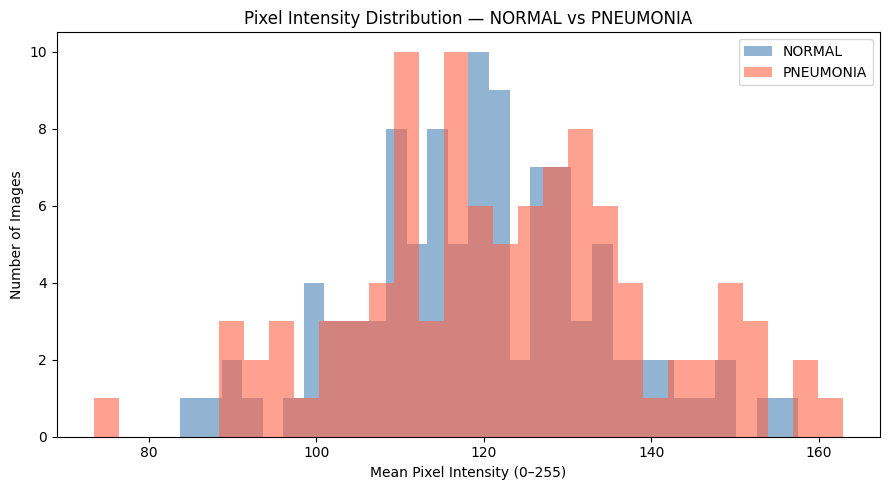

Saved: eda_pixel_intensity.png


In [29]:
# Histogram of pixel intensity distributions per class
fig, ax = plt.subplots(figsize=(9, 5))

for cls, color in zip(CLASSES, ['steelblue', 'tomato']):
    ax.hist(intensity_data[cls], bins=30, alpha=0.6, color=color, label=cls)

ax.set_xlabel('Mean Pixel Intensity (0–255)')
ax.set_ylabel('Number of Images')
ax.set_title('Pixel Intensity Distribution — NORMAL vs PNEUMONIA')
ax.legend()
plt.tight_layout()
plt.savefig('eda_pixel_intensity.png', dpi=150)
plt.show()
print('Saved: eda_pixel_intensity.png')

In [30]:
corrupted = []

for split in SPLITS:
    for cls in CLASSES:
        folder = os.path.join(DATA_DIR, split, cls)
        if not os.path.exists(folder):
            continue
        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()  # checks file integrity without fully loading
            except Exception as e:
                corrupted.append({'path': fpath, 'error': str(e)})

print(f'Total corrupted images found: {len(corrupted)}')
if corrupted:
    print('\nCorrupted files:')
    for item in corrupted:
        print(f"  {item['path']}  →  {item['error']}")
    print('\nAction: These will be skipped automatically by a custom Dataset class in training.')
else:
    print('No corrupted images found ✅')

Total corrupted images found: 0
No corrupted images found ✅


In [31]:
print('=' * 55)
print('            EDA SUMMARY & ACTION PLAN')
print('=' * 55)

# Class distribution
print('\n[1] Class Distribution')
for split in SPLITS:
    n = counts[split]['NORMAL']
    p = counts[split]['PNEUMONIA']
    print(f'    {split}: NORMAL={n}, PNEUMONIA={p}, Total={n+p}')

# Imbalance
print('\n[2] Class Imbalance (train split)')
n = counts['train']['NORMAL']
p = counts['train']['PNEUMONIA']
if n > 0:
    ratio = p / n
    print(f'    Ratio: {ratio:.2f}x')
    if ratio < 2:
        print('    → No action needed')
    elif ratio < 4:
        print('    → Add class_weight to loss function')
    else:
        print('    → Add class_weight + oversample NORMAL')

# Image sizes
print('\n[3] Image Sizes')
unique_sizes = len(set(zip(widths, heights)))
if unique_sizes == 1:
    print(f'    All images: {widths[0]}x{heights[0]} ✅')
else:
    print(f'    Varying sizes ({unique_sizes} unique) → Resize to 224x224 in transformation')

# Pixel intensity
print('\n[4] Pixel Intensity')
for cls in CLASSES:
    print(f'    {cls}: mean={np.mean(intensity_data[cls]):.1f}')
print('    → Apply ImageNet normalization (mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])')

# Corrupted
print('\n[5] Corrupted Images')
print(f'    Found: {len(corrupted)}')
if corrupted:
    print('    → Handle in custom Dataset class during training')
else:
    print('    → None, no action needed ✅')

print('\n' + '=' * 55)
print('Next step: Data Transformation component')
print('=' * 55)

            EDA SUMMARY & ACTION PLAN

[1] Class Distribution
    train: NORMAL=1341, PNEUMONIA=3875, Total=5216
    test: NORMAL=234, PNEUMONIA=390, Total=624
    val: NORMAL=8, PNEUMONIA=8, Total=16

[2] Class Imbalance (train split)
    Ratio: 2.89x
    → Add class_weight to loss function

[3] Image Sizes
    Varying sizes (199 unique) → Resize to 224x224 in transformation

[4] Pixel Intensity
    NORMAL: mean=119.6
    PNEUMONIA: mean=122.3
    → Apply ImageNet normalization (mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])

[5] Corrupted Images
    Found: 0
    → None, no action needed ✅

Next step: Data Transformation component
